In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()





Saving ai disaster management dataset.csv to ai disaster management dataset.csv


In [ ]:
df = pd.read_csv("/content/ai disaster management dataset.csv")

df.head()

,date,country,disaster_type,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,response_efficiency_score,recovery_days,latitude,longitude
0,2021-01-31,Brazil,Earthquake,5.99,111,7934365.71,15.62,271603.79,83.21,67,-30.613,-122.557
1,2018-12-23,Brazil,Extreme Heat,6.53,100,8307648.99,5.03,265873.81,96.18,55,10.859,-159.194
2,2020-08-10,India,Hurricane,1.55,22,765136.99,32.54,49356.49,60.40,22,0.643,-160.978
3,2022-09-15,Indonesia,Extreme Heat,4.55,94,1308251.31,7.83,237512.88,86.41,47,-33.547,30.350
4,2022-09-28,United States,Wildfire,3.80,64,2655864.36,21.90,188910.69,72.81,42,-19.170,-117.137


In [ ]:
india_df = df[df["country"] == "India"].copy()

print("Original dataset:", df.shape)
print("India dataset:", india_df.shape)

Original dataset: (50000, 12)
India dataset: (2509, 12)


In [ ]:
print(india_df["country"].unique())
print(india_df["disaster_type"].value_counts())

['India']
disaster_type
Landslide            269
Flood                266
Drought              266
Hurricane            265
Tornado              247
Wildfire             243
Storm Surge          241
Extreme Heat         241
Volcanic Eruption    240
Earthquake           231
Name: count, dtype: int64


In [ ]:
india_df.isnull().sum()
india_df.duplicated().sum()
india_df.describe()
india_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2509 entries, 2 to 49984
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       2509 non-null   object 
 1   country                    2509 non-null   object 
 2   disaster_type              2509 non-null   object 
 3   severity_index             2509 non-null   float64
 4   casualties                 2509 non-null   int64  
 5   economic_loss_usd          2509 non-null   float64
 6   response_time_hours        2509 non-null   float64
 7   aid_amount_usd             2509 non-null   float64
 8   response_efficiency_score  2509 non-null   float64
 9   recovery_days              2509 non-null   int64  
 10  latitude                   2509 non-null   float64
 11  longitude                  2509 non-null   float64
dtypes: float64(7), int64(2), object(3)
memory usage: 254.8+ KB


In [ ]:
y = india_df["severity_index"]
features = [
    "disaster_type",
    "casualties",
    "economic_loss_usd",
    "response_time_hours",
    "aid_amount_usd",
    "recovery_days",
    "latitude",
    "longitude"
]

X = india_df[features]
y = india_df["severity_index"]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["disaster_type"]

numeric_features = [
    "casualties",
    "economic_loss_usd",
    "response_time_hours",
    "aid_amount_usd",
    "recovery_days",
    "latitude",
    "longitude"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (2007, 8)
Testing: (502, 8)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['disaster_type']),
                                                 ('num', 'passthrough',
                                                  ['casualties',
                                                   'economic_loss_usd',
                                                   'response_time_hours',
                                                   'aid_amount_usd',
                                                   'recovery_days', 'latitude',
                                                   'longitude'])])),
                ('model', LinearRegression())])

In [ ]:
linear_predictions = linear_model.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("-----------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
-----------------
MAE : 0.34499222059987567
RMSE: 0.43458021771627287
R²  : 0.9505821647583028


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['disaster_type']),
                                                 ('num', 'passthrough',
                                                  ['casualties',
                                                   'economic_loss_usd',
                                                   'response_time_hours',
                                                   'aid_amount_usd',
                                                   'recovery_days', 'latitude',
                                                   'longitude'])])),
                ('model', KNeighborsRegressor())])

In [ ]:
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_test)

In [ ]:
knn_mae = mean_absolute_error(y_test, knn_predictions)

knn_rmse = np.sqrt(
    mean_squared_error(y_test, knn_predictions)
)

knn_r2 = r2_score(y_test, knn_predictions)

print("KNN Regressor")
print("----------------")
print("MAE :", knn_mae)
print("RMSE:", knn_rmse)
print("R²  :", knn_r2)

KNN Regressor
----------------
MAE : 0.9542430278884463
RMSE: 1.2355445047053424
R²  : 0.6005516811430669


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

In [ ]:
tree_mae = mean_absolute_error(y_test, tree_predictions)

tree_rmse = np.sqrt(
    mean_squared_error(y_test, tree_predictions)
)

tree_r2 = r2_score(y_test, tree_predictions)

print("Decision Tree Regressor")
print("----------------------")
print("MAE :", tree_mae)
print("RMSE:", tree_rmse)
print("R²  :", tree_r2)

Decision Tree Regressor
----------------------
MAE : 0.49667330677290844
RMSE: 0.6282815049023729
R²  : 0.8967114070112374


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Regressor")
print("-----------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Regressor
-----------------------
MAE : 0.3449900398406376
RMSE: 0.4391788994670075
R²  : 0.9495307625455065


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        knn_mae,
        tree_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        knn_rmse,
        tree_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        knn_r2,
        tree_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.344992,0.434580,0.950582
1,KNN,0.954243,1.235545,0.600552
2,Decision Tree,0.496673,0.628282,0.896711
3,Random Forest,0.344990,0.439179,0.949531


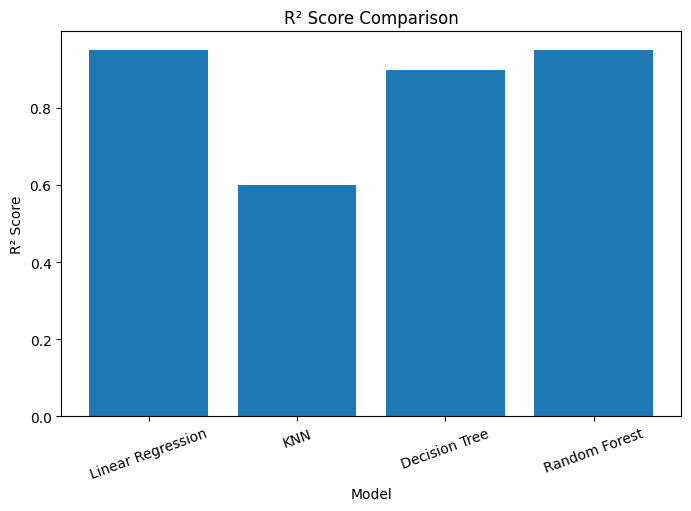

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["R2"])

plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title("R² Score Comparison")

plt.xticks(rotation=20)
plt.show()

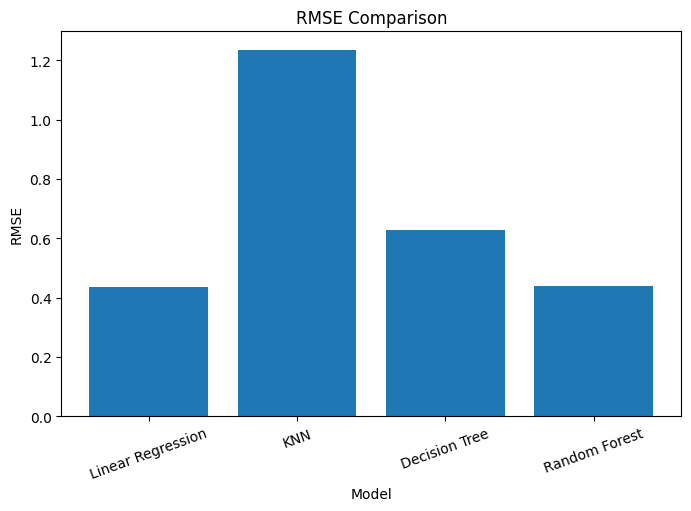

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["RMSE"])

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("RMSE Comparison")

plt.xticks(rotation=20)
plt.show()

In [ ]:
india_df.corr(numeric_only=True)["severity_index"].sort_values(
    ascending=False
)

,severity_index
severity_index,1.000000
recovery_days,0.966971
aid_amount_usd,0.664765
casualties,0.610467
response_efficiency_score,0.599829
economic_loss_usd,0.587426
longitude,0.031580
latitude,-0.026146
response_time_hours,-0.661094


In [ ]:
features_realistic = [
    "disaster_type",
    "casualties",
    "latitude",
    "longitude"
]

X = india_df[features_realistic]
y = india_df["severity_index"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["disaster_type"]

numeric_features = [
    "casualties",
    "latitude",
    "longitude"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

<Axes: >

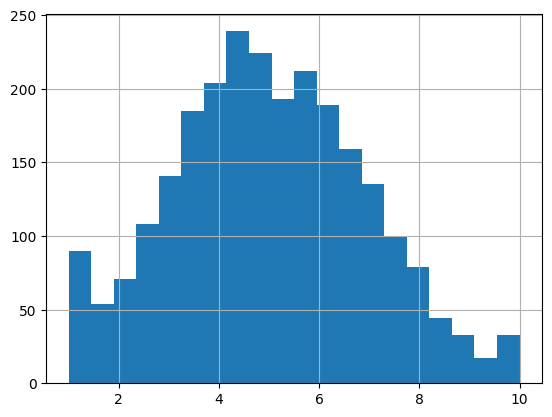

In [ ]:
india_df["severity_index"].describe()
india_df["severity_index"].hist(bins=20)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("-----------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
-----------------
MAE : 1.1449610875289762
RMSE: 1.4718570738523193
R²  : 0.43314094334532316


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)

In [ ]:
knn_mae = mean_absolute_error(y_test, knn_predictions)

knn_rmse = np.sqrt(
    mean_squared_error(y_test, knn_predictions)
)

knn_r2 = r2_score(y_test, knn_predictions)

print("KNN Regressor")
print("-------------")
print("MAE :", knn_mae)
print("RMSE:", knn_rmse)
print("R²  :", knn_r2)

KNN Regressor
-------------
MAE : 1.2358725099601593
RMSE: 1.5835210602348082
R²  : 0.343867578334746


In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

In [ ]:
tree_mae = mean_absolute_error(y_test, tree_predictions)

tree_rmse = np.sqrt(
    mean_squared_error(y_test, tree_predictions)
)

tree_r2 = r2_score(y_test, tree_predictions)

print("Decision Tree Regressor")
print("----------------------")
print("MAE :", tree_mae)
print("RMSE:", tree_rmse)
print("R²  :", tree_r2)

Decision Tree Regressor
----------------------
MAE : 1.683187250996016
RMSE: 2.142498913331229
R²  : -0.20111621913301403


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Regressor")
print("-----------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Regressor
-----------------------
MAE : 1.2330565737051793
RMSE: 1.5572557610293065
R²  : 0.36545313437638227


In [ ]:
results_realistic = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        knn_mae,
        tree_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        knn_rmse,
        tree_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        knn_r2,
        tree_r2,
        rf_r2
    ]
})

results_realistic.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
0,Linear Regression,1.144961,1.471857,0.433141
3,Random Forest,1.233057,1.557256,0.365453
1,KNN,1.235873,1.583521,0.343868
2,Decision Tree,1.683187,2.142499,-0.201116


In [ ]:
# Convert numerical severity into 4 categories

def classify_severity(value):
    if value <= 3:
        return "Low"
    elif value <= 5:
        return "Medium"
    elif value <= 7:
        return "High"
    else:
        return "Critical"

india_df["severity_class"] = india_df["severity_index"].apply(classify_severity)

# Check how many disasters are in each category
print(india_df["severity_class"].value_counts())

severity_class
Medium      915
High        815
Critical    392
Low         387
Name: count, dtype: int64


In [ ]:
# Features we will use to predict severity

features = [
    "disaster_type",
    "casualties",
    "latitude",
    "longitude"
]

X = india_df[features]

# Target = severity category
y = india_df["severity_class"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   disaster_type  casualties  latitude  longitude
2      Hurricane          22     0.643   -160.978
12   Storm Surge          50     4.097    -86.764
30         Flood         192    37.923    162.515
35       Drought          66    10.597    -91.761
37    Earthquake          70   -51.497    -89.078

Target:
2        Low
12    Medium
30      High
35    Medium
37      High
Name: severity_class, dtype: object


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2007, 4)
Testing data: (502, 4)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["disaster_type"]

numeric_features = [
    "casualties",
    "latitude",
    "longitude"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
logistic_predictions = logistic_model.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logistic_accuracy = accuracy_score(y_test, logistic_predictions)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Logistic Regression
-------------------
Accuracy : 0.5159362549800797
Precision: 0.5499671305248737
Recall   : 0.5159362549800797
F1 Score : 0.5128530687575457


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

# Train KNN
knn_model.fit(X_train, y_train)

# Make predictions
knn_predictions = knn_model.predict(X_test)

In [ ]:
knn_accuracy = accuracy_score(y_test, knn_predictions)

knn_precision = precision_score(
    y_test,
    knn_predictions,
    average="weighted",
    zero_division=0
)

knn_recall = recall_score(
    y_test,
    knn_predictions,
    average="weighted",
    zero_division=0
)

knn_f1 = f1_score(
    y_test,
    knn_predictions,
    average="weighted",
    zero_division=0
)

print("KNN Classifier")
print("--------------")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

KNN Classifier
--------------
Accuracy : 0.44621513944223107
Precision: 0.44705825273608857
Recall   : 0.44621513944223107
F1 Score : 0.44612970208781855


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Train
tree_model.fit(X_train, y_train)

# Predict
tree_predictions = tree_model.predict(X_test)

In [ ]:
tree_accuracy = accuracy_score(y_test, tree_predictions)

tree_precision = precision_score(
    y_test,
    tree_predictions,
    average="weighted",
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    tree_predictions,
    average="weighted",
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    tree_predictions,
    average="weighted",
    zero_division=0
)

print("Decision Tree Classifier")
print("------------------------")
print("Accuracy :", tree_accuracy)
print("Precision:", tree_precision)
print("Recall   :", tree_recall)
print("F1 Score :", tree_f1)

Decision Tree Classifier
------------------------
Accuracy : 0.3784860557768924
Precision: 0.38062408854241525
Recall   : 0.3784860557768924
F1 Score : 0.37730909018972814


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

print("Random Forest Classifier")
print("------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest Classifier
------------------------
Accuracy : 0.448207171314741
Precision: 0.45239331184402065
Recall   : 0.448207171314741
F1 Score : 0.44194586108292866


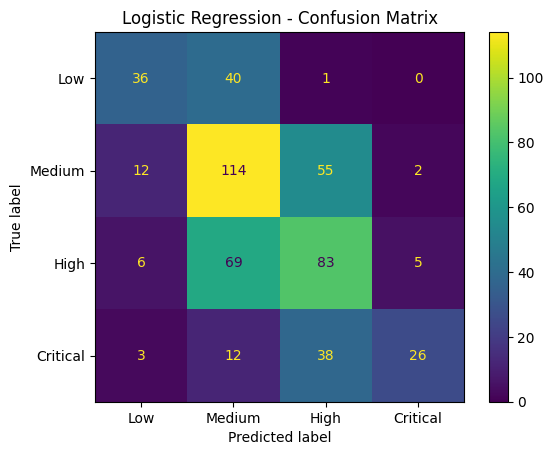

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    logistic_predictions,
    labels=["Low", "Medium", "High", "Critical"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High", "Critical"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
print(
    india_df["severity_class"]
    .value_counts()
    .reindex(["Low", "Medium", "High", "Critical"])
)
print(
    india_df["severity_class"]
    .value_counts(normalize=True)
    .reindex(["Low", "Medium", "High", "Critical"]) * 100
)

severity_class
Low         387
Medium      915
High        815
Critical    392
Name: count, dtype: int64
severity_class
Low         15.424472
Medium      36.468713
High        32.483061
Critical    15.623754
Name: proportion, dtype: float64


In [ ]:
print(india_df["disaster_type"].value_counts())
print(
    india_df.groupby("disaster_type")["severity_index"]
    .agg(["count", "mean", "min", "max"])
    .sort_values("mean", ascending=False)
)
print(
    india_df.groupby("severity_class")["casualties"]
    .agg(["count", "mean", "min", "max"])
)
pd.crosstab(
    india_df["disaster_type"],
    india_df["severity_class"],
    normalize="index"
).round(3)

disaster_type
Landslide            269
Flood                266
Drought              266
Hurricane            265
Tornado              247
Wildfire             243
Storm Surge          241
Extreme Heat         241
Volcanic Eruption    240
Earthquake           231
Name: count, dtype: int64
                   count      mean  min    max
disaster_type                                 
Tornado              247  5.197287  1.0   9.85
Volcanic Eruption    240  5.096708  1.0  10.00
Storm Surge          241  5.060705  1.0  10.00
Extreme Heat         241  5.058257  1.0  10.00
Landslide            269  5.021264  1.0  10.00
Drought              266  4.996090  1.0  10.00
Earthquake           231  4.973550  1.0  10.00
Hurricane            265  4.862981  1.0  10.00
Flood                266  4.858872  1.0  10.00
Wildfire             243  4.823292  1.0  10.00
                count        mean  min  max
severity_class                             
Critical          392  166.040816    1  429
High          

severity_class,Critical,High,Low,Medium
disaster_type,,,,
Drought,0.147,0.331,0.143,0.380
Earthquake,0.156,0.333,0.156,0.355
Extreme Heat,0.162,0.336,0.162,0.340
Flood,0.139,0.308,0.173,0.380
Hurricane,0.121,0.328,0.170,0.381
Landslide,0.152,0.346,0.167,0.335
Storm Surge,0.158,0.332,0.141,0.369
Tornado,0.186,0.348,0.105,0.360
Volcanic Eruption,0.200,0.296,0.154,0.350


In [ ]:

!pip install -q datasets

In [ ]:
from datasets import load_dataset

dataset = load_dataset("QCRI/HumAID-all")

README.md:   0%|          | 0.00/4.70k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/2.23k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 5.05MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

validation-00000-of-00001.parquet:   0%|          | 0.00/739k [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/53531 [00:00<?, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split:   0%|          | 0/15160 [00:00<?, ? examples/s]

ExpectedMoreSplitsError: {'dev'}

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "parquet",
    data_files={
        "train": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/train-00000-of-00001.parquet",
        "validation": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/validation-00000-of-00001.parquet",
        "test": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/test-00000-of-00001.parquet"
    }
)

print(dataset)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 53531
    })
    validation: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 7793
    })
    test: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 15160
    })
})


In [ ]:
print(dataset["train"].column_names)
print(dataset["train"][0])

['tweet_text', 'class_label']
{'tweet_text': 'Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people trapped un', 'class_label': 'injured_or_dead_people'}


In [ ]:
classes = dataset["train"].unique("class_label")

print("Number of classes:", len(classes))

for c in classes:
    print(c)

Number of classes: 10
injured_or_dead_people
rescue_volunteering_or_donation_effort
sympathy_and_support
infrastructure_and_utility_damage
requests_or_urgent_needs
other_relevant_information
caution_and_advice
not_humanitarian
displaced_people_and_evacuations
missing_or_found_people


In [ ]:
from collections import Counter

class_counts = Counter(dataset["train"]["class_label"])

print("Class distribution:\n")

for label, count in class_counts.most_common():
    print(label, ":", count)

Class distribution:

rescue_volunteering_or_donation_effort : 14891
other_relevant_information : 8501
sympathy_and_support : 6250
infrastructure_and_utility_damage : 5715
injured_or_dead_people : 5110
not_humanitarian : 4407
caution_and_advice : 3774
displaced_people_and_evacuations : 2800
requests_or_urgent_needs : 1833
missing_or_found_people : 250


In [ ]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (53531, 2)
Validation: (7793, 2)
Test: (15160, 2)


In [ ]:
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nDuplicate tweets:")
print(train_df["tweet_text"].duplicated().sum())
train_df.head(10)

Missing values in training data:
tweet_text     0
class_label    0
dtype: int64

Duplicate tweets:
0


,tweet_text,class_label
0,Powerful Ecuador quake kills at least 235: POR...,injured_or_dead_people
1,Im at awe and saddened with the #EcuadorEarthq...,rescue_volunteering_or_donation_effort
2,RT @RachelAndJun: Our hearts are with everyone...,sympathy_and_support
3,RT @noticias2000: Ecuador quake death toll has...,injured_or_dead_people
4,RT @pzf: BREAKING PHOTOS: Major damage reporte...,infrastructure_and_utility_damage
5,"Official death toll now 233, says President Co...",injured_or_dead_people
6,RT @thejpc: Israeli relief org already in Japa...,rescue_volunteering_or_donation_effort
7,RT @SamaritansPurse: We are rushing aid to hel...,rescue_volunteering_or_donation_effort
8,RT @GConnaughton: #Toronto &amp; #Canadian fir...,rescue_volunteering_or_donation_effort
9,"#Ecuador #earthquake in #USA, 272 people killed",injured_or_dead_people


In [ ]:
import re

def clean_text(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove @mentions
    text = re.sub(r"@\w+", "", text)

    # Remove the # symbol but keep the hashtag word
    text = re.sub(r"#", "", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
train_df["clean_text"] = train_df["tweet_text"].apply(clean_text)
val_df["clean_text"] = val_df["tweet_text"].apply(clean_text)
test_df["clean_text"] = test_df["tweet_text"].apply(clean_text)

In [ ]:
print("Original:")
print(train_df["tweet_text"].iloc[0])

print("\nCleaned:")
print(train_df["clean_text"].iloc[0])

Original:
Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people trapped un

Cleaned:
powerful ecuador quake kills at least portoviejo rescuers in ecuador raced to dig out people trapped un


In [ ]:
X_train = train_df["clean_text"]
y_train = train_df["class_label"]

X_val = val_df["clean_text"]
y_val = val_df["class_label"]

X_test = test_df["clean_text"]
y_test = test_df["class_label"]

In [ ]:
print(X_train.iloc[0])
print(y_train.iloc[0])

powerful ecuador quake kills at least portoviejo rescuers in ecuador raced to dig out people trapped un
injured_or_dead_people


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

X_test_tfidf = tfidf.transform(X_test)

print("Training matrix:", X_train_tfidf.shape)
print("Validation matrix:", X_val_tfidf.shape)
print("Testing matrix:", X_test_tfidf.shape)

Training matrix: (53531, 10000)
Validation matrix: (7793, 10000)
Testing matrix: (15160, 10000)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

logistic_model = LogisticRegression(
    max_iter=1000
)

# Train the model
logistic_model.fit(X_train_tfidf, y_train)

# Predict on test data
logistic_predictions = logistic_model.predict(X_test_tfidf)

In [ ]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Logistic Regression
-------------------
Accuracy : 0.7474934036939314
Precision: 0.7487049242033591
Recall   : 0.7474934036939314
F1 Score : 0.7448818242884555


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

# Train
nb_model.fit(X_train_tfidf, y_train)

# Predict
nb_predictions = nb_model.predict(X_test_tfidf)

In [ ]:
nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

nb_precision = precision_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

nb_recall = recall_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

nb_f1 = f1_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

print("Naive Bayes")
print("------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Naive Bayes
------------
Accuracy : 0.6860817941952506
Precision: 0.6892116073968785
Recall   : 0.6860817941952506
F1 Score : 0.6726406727178739


In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42
)

# Train
svm_model.fit(X_train_tfidf, y_train)

# Predict
svm_predictions = svm_model.predict(X_test_tfidf)

In [ ]:
svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_precision = precision_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

print("Linear SVM")
print("----------")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

Linear SVM
----------
Accuracy : 0.7347625329815304
Precision: 0.7288764667473986
Recall   : 0.7347625329815304
F1 Score : 0.7305778499806611


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train_tfidf, y_train)

# Predict
rf_predictions = rf_model.predict(X_test_tfidf)

In [ ]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

print("Random Forest")
print("-------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
-------------
Accuracy : 0.7162269129287598
Precision: 0.7158113370925271
Recall   : 0.7162269129287598
F1 Score : 0.7047675245015913


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    logistic_predictions,
    zero_division=0
))



                                        precision    recall  f1-score   support

                    caution_and_advice       0.73      0.57      0.64      1070
      displaced_people_and_evacuations       0.90      0.83      0.87       790
     infrastructure_and_utility_damage       0.80      0.81      0.80      1617
                injured_or_dead_people       0.90      0.90      0.90      1447
               missing_or_found_people       0.84      0.57      0.68        72
                      not_humanitarian       0.59      0.49      0.53      1245
            other_relevant_information       0.54      0.61      0.57      2407
              requests_or_urgent_needs       0.61      0.43      0.51       521
rescue_volunteering_or_donation_effort       0.80      0.89      0.84      4219
                  sympathy_and_support       0.85      0.76      0.80      1772

                              accuracy                           0.75     15160
                             macro avg

In [ ]:
from sklearn.linear_model import LogisticRegression

weighted_logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

# Train
weighted_logistic_model.fit(
    X_train_tfidf,
    y_train
)

# Predict
weighted_logistic_predictions = weighted_logistic_model.predict(
    X_test_tfidf
)

In [ ]:
weighted_accuracy = accuracy_score(
    y_test,
    weighted_logistic_predictions
)

weighted_precision = precision_score(
    y_test,
    weighted_logistic_predictions,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_test,
    weighted_logistic_predictions,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    weighted_logistic_predictions,
    average="weighted",
    zero_division=0
)

print("Class-Weighted Logistic Regression")
print("-----------------------------------")
print("Accuracy :", weighted_accuracy)
print("Precision:", weighted_precision)
print("Recall   :", weighted_recall)
print("F1 Score :", weighted_f1)

Class-Weighted Logistic Regression
-----------------------------------
Accuracy : 0.7285620052770448
Precision: 0.7434626979572059
Recall   : 0.7285620052770448
F1 Score : 0.7319759382585161


In [ ]:
print(classification_report(
    y_test,
    weighted_logistic_predictions,
    zero_division=0
))

                                        precision    recall  f1-score   support

                    caution_and_advice       0.62      0.71      0.66      1070
      displaced_people_and_evacuations       0.83      0.89      0.86       790
     infrastructure_and_utility_damage       0.78      0.81      0.80      1617
                injured_or_dead_people       0.89      0.89      0.89      1447
               missing_or_found_people       0.47      0.82      0.60        72
                      not_humanitarian       0.51      0.63      0.56      1245
            other_relevant_information       0.57      0.48      0.52      2407
              requests_or_urgent_needs       0.42      0.72      0.53       521
rescue_volunteering_or_donation_effort       0.87      0.77      0.82      4219
                  sympathy_and_support       0.83      0.77      0.80      1772

                              accuracy                           0.73     15160
                             macro avg

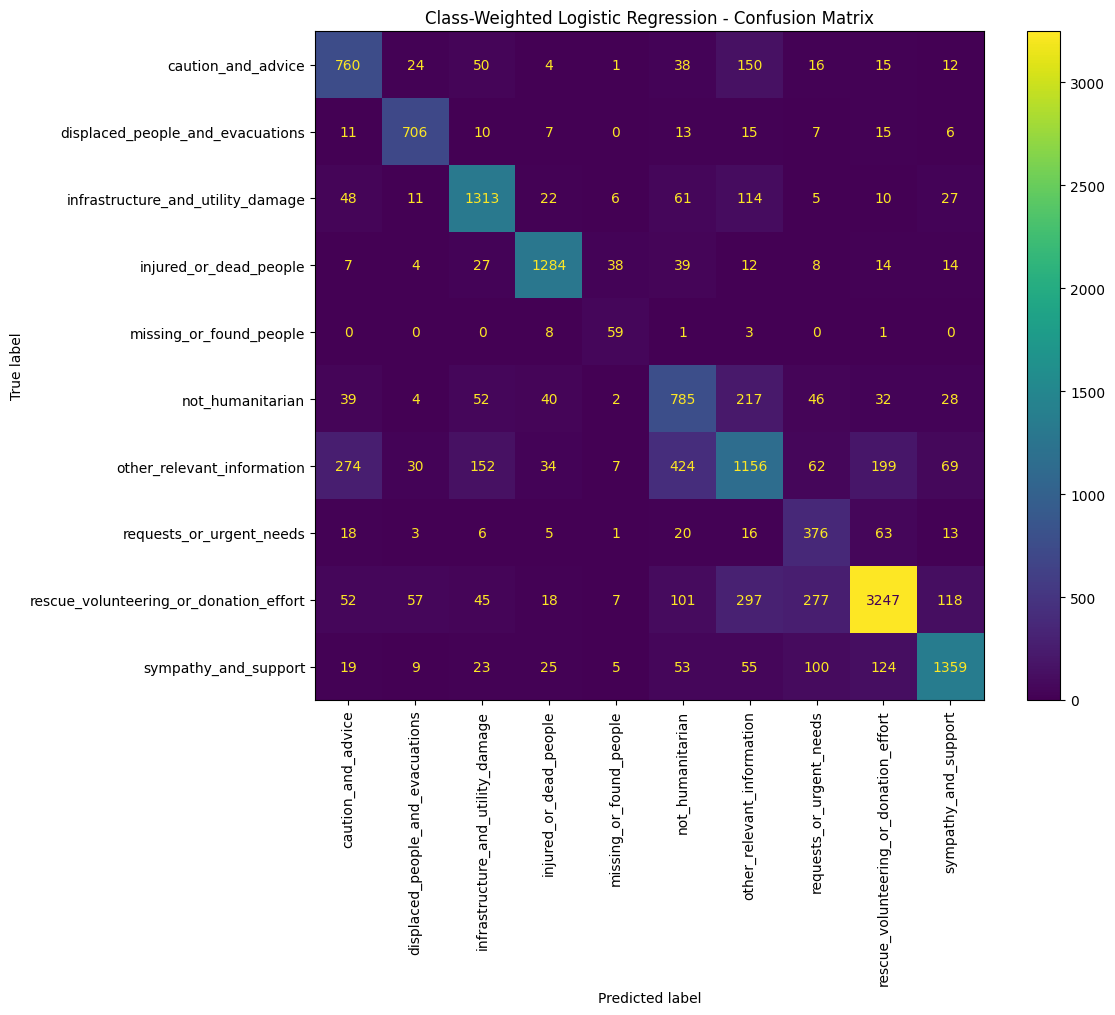

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    weighted_logistic_predictions,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(12, 10))

disp.plot(
    ax=ax,
    xticks_rotation=90
)

plt.title("Class-Weighted Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_v2 = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_v2 = tfidf_v2.fit_transform(X_train)
X_val_v2 = tfidf_v2.transform(X_val)
X_test_v2 = tfidf_v2.transform(X_test)

print("Training:", X_train_v2.shape)
print("Validation:", X_val_v2.shape)
print("Testing:", X_test_v2.shape)

Training: (53531, 30000)
Validation: (7793, 30000)
Testing: (15160, 30000)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_v2 = LogisticRegression(
    C=1,
    max_iter=1000
)

lr_v2.fit(X_train_v2, y_train)

val_predictions_v2 = lr_v2.predict(X_val_v2)

print("Validation Accuracy:",
      accuracy_score(y_val, val_predictions_v2))

print("Validation F1:",
      f1_score(
          y_val,
          val_predictions_v2,
          average="weighted"
      ))

Validation Accuracy: 0.7411779802386758
Validation F1: 0.7384109041127922


In [ ]:
lr_v2_weighted = LogisticRegression(
    C=1,
    max_iter=1000,
    class_weight="balanced"
)

lr_v2_weighted.fit(X_train_v2, y_train)

val_predictions_v2_weighted = lr_v2_weighted.predict(X_val_v2)

print("Weighted Logistic Regression - V2")
print("----------------------------------")

print(
    "Validation Accuracy:",
    accuracy_score(y_val, val_predictions_v2_weighted)
)

print(
    "Validation Precision:",
    precision_score(
        y_val,
        val_predictions_v2_weighted,
        average="weighted",
        zero_division=0
    )
)

print(
    "Validation Recall:",
    recall_score(
        y_val,
        val_predictions_v2_weighted,
        average="weighted",
        zero_division=0
    )
)

print(
    "Validation F1:",
    f1_score(
        y_val,
        val_predictions_v2_weighted,
        average="weighted",
        zero_division=0
    )
)

Weighted Logistic Regression - V2
----------------------------------
Validation Accuracy: 0.7275760297703067
Validation Precision: 0.740115954329922
Validation Recall: 0.7275760297703067
Validation F1: 0.7307194027923491


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

for C in [0.1, 0.5, 1, 2, 5]:

    svm = LinearSVC(
        C=C,
        class_weight="balanced",
        random_state=42
    )

    svm.fit(X_train_tfidf, y_train)

    val_pred = svm.predict(X_val_tfidf)

    accuracy = accuracy_score(y_val, val_pred)
    f1 = f1_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    print(
        "C =", C,
        "| Accuracy =", round(accuracy, 4),
        "| F1 =", round(f1, 4)
    )

C = 0.1 | Accuracy = 0.7341 | F1 = 0.7312
C = 0.5 | Accuracy = 0.7336 | F1 = 0.7319
C = 1 | Accuracy = 0.7235 | F1 = 0.722
C = 2 | Accuracy = 0.7138 | F1 = 0.7125
C = 5 | Accuracy = 0.6963 | F1 = 0.6952


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Word-level TF-IDF
word_tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Character-level TF-IDF
char_tfidf = TfidfVectorizer(
    analyzer="char",
    max_features=20000,
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True
)

X_train_word = word_tfidf.fit_transform(X_train)
X_val_word = word_tfidf.transform(X_val)

X_train_char = char_tfidf.fit_transform(X_train)
X_val_char = char_tfidf.transform(X_val)

# Combine them
X_train_combined = hstack([
    X_train_word,
    X_train_char
])

X_val_combined = hstack([
    X_val_word,
    X_val_char
])

print("Training shape:", X_train_combined.shape)
print("Validation shape:", X_val_combined.shape)

Training shape: (53531, 40000)
Validation shape: (7793, 40000)


In [ ]:
from sklearn.svm import LinearSVC

combined_svm = LinearSVC(
    C=0.5,
    class_weight="balanced",
    random_state=42
)

combined_svm.fit(
    X_train_combined,
    y_train
)

combined_predictions = combined_svm.predict(
    X_val_combined
)

In [ ]:
print("Word + Character TF-IDF + SVM")

print(
    "Accuracy:",
    accuracy_score(y_val, combined_predictions)
)

print(
    "F1:",
    f1_score(
        y_val,
        combined_predictions,
        average="weighted",
        zero_division=0
    )
)

Word + Character TF-IDF + SVM
Accuracy: 0.7338637238547414
F1: 0.7324160348716215


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

for C in [0.01, 0.05, 0.1, 0.5, 1, 2, 5]:

    model = LogisticRegression(
        C=C,
        max_iter=1000,
        class_weight="balanced"
    )

    model.fit(X_train_tfidf, y_train)

    predictions = model.predict(X_val_tfidf)

    accuracy = accuracy_score(y_val, predictions)

    f1 = f1_score(
        y_val,
        predictions,
        average="weighted",
        zero_division=0
    )

    print(
        "C =", C,
        "| Accuracy =", round(accuracy, 4),
        "| F1 =", round(f1, 4)
    )

C = 0.01 | Accuracy = 0.6191 | F1 = 0.6068
C = 0.05 | Accuracy = 0.6711 | F1 = 0.6711
C = 0.1 | Accuracy = 0.6897 | F1 = 0.6929
C = 0.5 | Accuracy = 0.7187 | F1 = 0.7231
C = 1 | Accuracy = 0.7239 | F1 = 0.7274
C = 2 | Accuracy = 0.725 | F1 = 0.7278
C = 5 | Accuracy = 0.721 | F1 = 0.7239


In [ ]:
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.3 MB/s eta 0:00:00


In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "parquet",
    data_files={
        "train": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/train-00000-of-00001.parquet",
        "validation": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/validation-00000-of-00001.parquet",
        "test": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/test-00000-of-00001.parquet"
    }
)

print(dataset)

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 5.05MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

validation-00000-of-00001.parquet:   0%|          | 0.00/739k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.44MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 53531
    })
    validation: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 7793
    })
    test: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 15160
    })
})


In [ ]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (53531, 2)
Validation: (7793, 2)
Test: (15160, 2)


In [ ]:
labels = sorted(train_df["class_label"].unique())

label2id = {
    label: i
    for i, label in enumerate(labels)
}

id2label = {
    i: label
    for i, label in enumerate(labels)
}

print("Number of classes:", len(labels))

for i, label in enumerate(labels):
    print(i, "→", label)

Number of classes: 10
0 → caution_and_advice
1 → displaced_people_and_evacuations
2 → infrastructure_and_utility_damage
3 → injured_or_dead_people
4 → missing_or_found_people
5 → not_humanitarian
6 → other_relevant_information
7 → requests_or_urgent_needs
8 → rescue_volunteering_or_donation_effort
9 → sympathy_and_support


In [ ]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
text = train_df["tweet_text"].iloc[0]

tokens = tokenizer(
    text,
    truncation=True,
    padding="max_length",
    max_length=128
)

print("Original:")
print(text)

print("\nToken IDs:")
print(tokens["input_ids"][:20])

print("\nAttention mask:")
print(tokens["attention_mask"][:20])

Original:
Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people trapped un

Token IDs:
[101, 3928, 10378, 27785, 8563, 2012, 2560, 17825, 1024, 13809, 13469, 5558, 1011, 5343, 2869, 1999, 10378, 8255, 2000, 10667]

Attention mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
# Convert text labels into numbers

train_df["label"] = train_df["class_label"].map(label2id)
val_df["label"] = val_df["class_label"].map(label2id)
test_df["label"] = test_df["class_label"].map(label2id)

print(train_df[["tweet_text", "class_label", "label"]].head())

                                          tweet_text  \
0  Powerful Ecuador quake kills at least 235: POR...   
1  Im at awe and saddened with the #EcuadorEarthq...   
2  RT @RachelAndJun: Our hearts are with everyone...   
3  RT @noticias2000: Ecuador quake death toll has...   
4  RT @pzf: BREAKING PHOTOS: Major damage reporte...   

                              class_label  label  
0                  injured_or_dead_people      3  
1  rescue_volunteering_or_donation_effort      8  
2                    sympathy_and_support      9  
3                  injured_or_dead_people      3  
4       infrastructure_and_utility_damage      2  


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["tweet_text", "label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["tweet_text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["tweet_text", "label"]]
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['tweet_text', 'label'],
    num_rows: 53531
})
Dataset({
    features: ['tweet_text', 'label'],
    num_rows: 7793
})
Dataset({
    features: ['tweet_text', 'label'],
    num_rows: 15160
})


In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["tweet_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/53531 [00:00<?, ? examples/s]

Map:   0%|          | 0/7793 [00:00<?, ? examples/s]

Map:   0%|          | 0/15160 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

print("Model loaded!")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!


In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./resqai_distilbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none",
    fp16=True
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.633168,0.637774


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3346, training_loss=0.7589523038391004, metrics={'train_runtime': 204.7403, 'train_samples_per_second': 261.458, 'train_steps_per_second': 16.343, 'total_flos': 1773030999206400.0, 'train_loss': 0.7589523038391004, 'epoch': 1.0})

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

predictions = trainer.predict(val_tokenized)

predicted_labels = predictions.predictions.argmax(axis=1)
true_labels = predictions.label_ids

accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

f1 = f1_score(
    true_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)

print("DistilBERT - Validation Results")
print("--------------------------------")
print("Accuracy:", accuracy)
print("F1 Score:", f1)

DistilBERT - Validation Results
--------------------------------
Accuracy: 0.7763377389965354
F1 Score: 0.7716421351053536


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=labels,
        zero_division=0
    )
)

                                        precision    recall  f1-score   support

                    caution_and_advice       0.71      0.67      0.69       550
      displaced_people_and_evacuations       0.88      0.93      0.91       409
     infrastructure_and_utility_damage       0.77      0.83      0.80       831
                injured_or_dead_people       0.91      0.95      0.93       746
               missing_or_found_people       0.81      0.72      0.76        36
                      not_humanitarian       0.64      0.55      0.59       644
            other_relevant_information       0.60      0.53      0.56      1236
              requests_or_urgent_needs       0.60      0.57      0.59       264
rescue_volunteering_or_donation_effort       0.84      0.91      0.87      2168
                  sympathy_and_support       0.86      0.81      0.84       909

                              accuracy                           0.78      7793
                             macro avg

In [ ]:
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(labels)),
    y=train_df["label"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)

print("Class weights:")
for i, weight in enumerate(class_weights):
    print(labels[i], ":", round(weight.item(), 3))

Class weights:
caution_and_advice : 1.418
displaced_people_and_evacuations : 1.912
infrastructure_and_utility_damage : 0.937
injured_or_dead_people : 1.048
missing_or_found_people : 21.412
not_humanitarian : 1.215
other_relevant_information : 0.63
requests_or_urgent_needs : 2.92
rescue_volunteering_or_donation_effort : 0.359
sympathy_and_support : 0.856


In [ ]:
class_weights_capped = np.clip(
    class_weights.numpy(),
    0.5,
    4.0
)

class_weights_capped = torch.tensor(
    class_weights_capped,
    dtype=torch.float
)

print("Capped class weights:")

for i, weight in enumerate(class_weights_capped):
    print(
        labels[i],
        ":",
        round(weight.item(), 3)
    )

Capped class weights:
caution_and_advice : 1.418
displaced_people_and_evacuations : 1.912
infrastructure_and_utility_damage : 0.937
injured_or_dead_people : 1.048
missing_or_found_people : 4.0
not_humanitarian : 1.215
other_relevant_information : 0.63
requests_or_urgent_needs : 2.92
rescue_volunteering_or_donation_effort : 0.5
sympathy_and_support : 0.856


In [ ]:
from transformers import AutoModelForSequenceClassification

weighted_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import torch
from transformers import Trainer

class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels_batch = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits

        loss_function = torch.nn.CrossEntropyLoss(
            weight=class_weights_capped.to(logits.device)
        )

        loss = loss_function(
            logits.view(-1, self.model.config.num_labels),
            labels_batch.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [ ]:
from transformers import TrainingArguments

weighted_training_args = TrainingArguments(
    output_dir="./resqai_distilbert_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none",
    fp16=True
)

In [ ]:
weighted_trainer = WeightedTrainer(
    model=weighted_model,
    args=weighted_training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized
)
weighted_trainer.train()

Epoch,Training Loss,Validation Loss
1,0.646492,0.660040


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3346, training_loss=0.7923800923905541, metrics={'train_runtime': 218.2185, 'train_samples_per_second': 245.309, 'train_steps_per_second': 15.333, 'total_flos': 1773030999206400.0, 'train_loss': 0.7923800923905541, 'epoch': 1.0})

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

weighted_predictions_output = weighted_trainer.predict(
    val_tokenized
)

weighted_predicted_labels = (
    weighted_predictions_output.predictions.argmax(axis=1)
)

weighted_true_labels = weighted_predictions_output.label_ids

weighted_accuracy = accuracy_score(
    weighted_true_labels,
    weighted_predicted_labels
)

weighted_f1 = f1_score(
    weighted_true_labels,
    weighted_predicted_labels,
    average="weighted",
    zero_division=0
)

print("Class-Weighted DistilBERT")
print("-------------------------")
print("Accuracy:", weighted_accuracy)
print("F1 Score:", weighted_f1)

Class-Weighted DistilBERT
-------------------------
Accuracy: 0.7619658668035416
F1 Score: 0.7560831055459214


In [ ]:
from transformers import AutoModelForSequenceClassification

model_3epoch = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    predictions, labels_actual = eval_pred

    predictions = predictions.argmax(axis=1)

    accuracy = accuracy_score(
        labels_actual,
        predictions
    )

    f1 = f1_score(
        labels_actual,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "f1": f1
    }

In [ ]:
from transformers import TrainingArguments

training_args_3epoch = TrainingArguments(
    output_dir="./resqai_distilbert_3epoch",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_steps=100,

    report_to="none",

    fp16=True,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1
)

In [ ]:
from transformers import Trainer

trainer_3epoch = Trainer(
    model=model_3epoch,
    args=training_args_3epoch,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    compute_metrics=compute_metrics
)

In [ ]:
trainer_3epoch.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.639725,0.659428,0.767099,0.757994
2,0.520739,0.634073,0.775824,0.772214
3,0.448193,0.658915,0.774798,0.771078


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=10038, training_loss=0.5753145268248904, metrics={'train_runtime': 631.6824, 'train_samples_per_second': 254.231, 'train_steps_per_second': 15.891, 'total_flos': 5319092997619200.0, 'train_loss': 0.5753145268248904, 'epoch': 3.0})

In [ ]:
best_predictions = trainer_3epoch.predict(
    val_tokenized
)

best_predicted_labels = best_predictions.predictions.argmax(axis=1)
best_true_labels = best_predictions.label_ids

print(
    classification_report(
        best_true_labels,
        best_predicted_labels,
        target_names=labels,
        zero_division=0
    )
)

                                        precision    recall  f1-score   support

                    caution_and_advice       0.65      0.78      0.71       550
      displaced_people_and_evacuations       0.89      0.90      0.90       409
     infrastructure_and_utility_damage       0.75      0.85      0.80       831
                injured_or_dead_people       0.93      0.95      0.94       746
               missing_or_found_people       0.81      0.69      0.75        36
                      not_humanitarian       0.63      0.58      0.60       644
            other_relevant_information       0.60      0.50      0.54      1236
              requests_or_urgent_needs       0.62      0.62      0.62       264
rescue_volunteering_or_donation_effort       0.86      0.88      0.87      2168
                  sympathy_and_support       0.86      0.83      0.84       909

                              accuracy                           0.78      7793
                             macro avg

In [ ]:
!pip install emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 14.8 MB/s eta 0:00:00


In [ ]:
from transformers import AutoTokenizer

bertweet_tokenizer = AutoTokenizer.from_pretrained(
    "vinai/bertweet-base",
    use_fast=False
)

print("BERTweet tokenizer loaded!")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

BERTweet tokenizer loaded!


In [ ]:
def bertweet_tokenize_function(examples):
    return bertweet_tokenizer(
        examples["tweet_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [ ]:
bertweet_train = train_dataset.map(
    bertweet_tokenize_function,
    batched=True
)

bertweet_val = val_dataset.map(
    bertweet_tokenize_function,
    batched=True
)

bertweet_test = test_dataset.map(
    bertweet_tokenize_function,
    batched=True
)

Map:   0%|          | 0/53531 [00:00<?, ? examples/s]

Map:   0%|          | 0/7793 [00:00<?, ? examples/s]

Map:   0%|          | 0/15160 [00:00<?, ? examples/s]

In [ ]:
print(bertweet_train.column_names)

['tweet_text', 'label', 'input_ids', 'attention_mask']


In [ ]:
from transformers import AutoModelForSequenceClassification

bertweet_model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/bertweet-base",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

print("BERTweet model loaded!")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  543MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTweet model loaded!


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics_bertweet(eval_pred):
    predictions, labels_actual = eval_pred

    predictions = predictions.argmax(axis=1)

    accuracy = accuracy_score(
        labels_actual,
        predictions
    )

    f1 = f1_score(
        labels_actual,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "f1": f1
    }

In [ ]:
from transformers import TrainingArguments

bertweet_training_args = TrainingArguments(
    output_dir="./resqai_bertweet",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=1,

    weight_decay=0.01,

    logging_steps=100,

    report_to="none",

    fp16=True,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1
)

In [ ]:
from transformers import Trainer

bertweet_trainer = Trainer(
    model=bertweet_model,
    args=bertweet_training_args,

    train_dataset=bertweet_train,
    eval_dataset=bertweet_val,

    compute_metrics=compute_metrics_bertweet
)

In [ ]:
bertweet_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.631815,0.630117,0.781471,0.776034


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6692, training_loss=0.73941939103696, metrics={'train_runtime': 543.7425, 'train_samples_per_second': 98.449, 'train_steps_per_second': 12.307, 'total_flos': 3521402395961856.0, 'train_loss': 0.73941939103696, 'epoch': 1.0})

In [ ]:
bertweet_predictions = bertweet_trainer.predict(
    bertweet_val
)

bertweet_predicted_labels = (
    bertweet_predictions.predictions.argmax(axis=1)
)

bertweet_true_labels = (
    bertweet_predictions.label_ids
)

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        bertweet_true_labels,
        bertweet_predicted_labels,
        target_names=labels,
        zero_division=0
    )
)

                                        precision    recall  f1-score   support

                    caution_and_advice       0.74      0.68      0.71       550
      displaced_people_and_evacuations       0.87      0.93      0.90       409
     infrastructure_and_utility_damage       0.76      0.85      0.80       831
                injured_or_dead_people       0.91      0.95      0.93       746
               missing_or_found_people       0.90      0.72      0.80        36
                      not_humanitarian       0.65      0.57      0.61       644
            other_relevant_information       0.61      0.52      0.56      1236
              requests_or_urgent_needs       0.61      0.59      0.60       264
rescue_volunteering_or_donation_effort       0.83      0.91      0.87      2168
                  sympathy_and_support       0.88      0.83      0.85       909

                              accuracy                           0.78      7793
                             macro avg

In [ ]:
bertweet_trainer.args.num_train_epochs = 2

bertweet_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.638187,0.654807,0.775439,0.765213
2,0.430387,0.713637,0.781984,0.777781


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=13384, training_loss=0.5289079993339763, metrics={'train_runtime': 1230.5535, 'train_samples_per_second': 87.003, 'train_steps_per_second': 10.876, 'total_flos': 7042804791923712.0, 'train_loss': 0.5289079993339763, 'epoch': 2.0})

In [ ]:
bertweet_2_predictions = bertweet_trainer.predict(
    bertweet_val
)

bertweet_2_predicted = (
    bertweet_2_predictions.predictions.argmax(axis=1)
)

bertweet_2_true = bertweet_2_predictions.label_ids

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

print("BERTweet - 2 Epochs")
print("-------------------")
print(
    "Accuracy:",
    accuracy_score(
        bertweet_2_true,
        bertweet_2_predicted
    )
)

print(
    "F1:",
    f1_score(
        bertweet_2_true,
        bertweet_2_predicted,
        average="weighted",
        zero_division=0
    )
)

BERTweet - 2 Epochs
-------------------
Accuracy: 0.7819838316437829
F1: 0.7777806202632516


In [ ]:
print(
    classification_report(
        bertweet_2_true,
        bertweet_2_predicted,
        target_names=labels,
        zero_division=0
    )
)

                                        precision    recall  f1-score   support

                    caution_and_advice       0.69      0.72      0.71       550
      displaced_people_and_evacuations       0.88      0.91      0.89       409
     infrastructure_and_utility_damage       0.76      0.81      0.79       831
                injured_or_dead_people       0.92      0.94      0.93       746
               missing_or_found_people       0.81      0.72      0.76        36
                      not_humanitarian       0.66      0.60      0.63       644
            other_relevant_information       0.62      0.52      0.57      1236
              requests_or_urgent_needs       0.60      0.61      0.60       264
rescue_volunteering_or_donation_effort       0.85      0.90      0.87      2168
                  sympathy_and_support       0.84      0.85      0.85       909

                              accuracy                           0.78      7793
                             macro avg

In [ ]:
# Final evaluation on the unseen TEST set

final_predictions = bertweet_trainer.predict(
    bertweet_test
)

final_predicted_labels = (
    final_predictions.predictions.argmax(axis=1)
)

final_true_labels = final_predictions.label_ids

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

final_accuracy = accuracy_score(
    final_true_labels,
    final_predicted_labels
)

final_f1 = f1_score(
    final_true_labels,
    final_predicted_labels,
    average="weighted",
    zero_division=0
)

print("FINAL BERTweet TEST RESULTS")
print("---------------------------")
print("Accuracy:", final_accuracy)
print("Weighted F1:", final_f1)

FINAL BERTweet TEST RESULTS
---------------------------
Accuracy: 0.787401055408971
Weighted F1: 0.7827254876494095


In [ ]:
print(
    classification_report(
        final_true_labels,
        final_predicted_labels,
        target_names=labels,
        zero_division=0
    )
)

                                        precision    recall  f1-score   support

                    caution_and_advice       0.70      0.71      0.71      1070
      displaced_people_and_evacuations       0.87      0.92      0.89       790
     infrastructure_and_utility_damage       0.80      0.83      0.82      1617
                injured_or_dead_people       0.92      0.95      0.93      1447
               missing_or_found_people       0.78      0.81      0.79        72
                      not_humanitarian       0.65      0.60      0.62      1245
            other_relevant_information       0.62      0.52      0.57      2407
              requests_or_urgent_needs       0.63      0.60      0.61       521
rescue_volunteering_or_donation_effort       0.85      0.92      0.88      4219
                  sympathy_and_support       0.85      0.84      0.84      1772

                              accuracy                           0.79     15160
                             macro avg

In [ ]:
import numpy as np

train_lengths = np.array([
    sum(mask)
    for mask in bertweet_train["attention_mask"]
])

val_lengths = np.array([
    sum(mask)
    for mask in bertweet_val["attention_mask"]
])

print("Training tweets:")
print("Average tokens:", train_lengths.mean())
print("Maximum tokens:", train_lengths.max())
print("At 128 tokens:", np.mean(train_lengths >= 128) * 100, "%")

print()

print("Validation tweets:")
print("Average tokens:", val_lengths.mean())
print("Maximum tokens:", val_lengths.max())
print("At 128 tokens:", np.mean(val_lengths >= 128) * 100, "%")

Training tweets:
Average tokens: 35.01526218452859
Maximum tokens: 128
At 128 tokens: 0.09900805140946368 %

Validation tweets:
Average tokens: 34.97061465417683
Maximum tokens: 128
At 128 tokens: 0.038496086231233156 %


In [ ]:
from transformers import EarlyStoppingCallback

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "parquet",
    data_files={
        "train": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/train-00000-of-00001.parquet",
        "validation": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/validation-00000-of-00001.parquet",
        "test": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/test-00000-of-00001.parquet"
    }
)

print(dataset)

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 5.05MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

validation-00000-of-00001.parquet:   0%|          | 0.00/739k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.44MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 53531
    })
    validation: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 7793
    })
    test: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 15160
    })
})


In [ ]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (53531, 2)
Validation: (7793, 2)
Test: (15160, 2)


In [ ]:
# Recreate label mappings

labels = sorted(train_df["class_label"].unique())

label2id = {
    label: i
    for i, label in enumerate(labels)
}

id2label = {
    i: label
    for label, i in label2id.items()
}

print("Number of labels:", len(labels))
print(labels)

Number of labels: 10
['caution_and_advice', 'displaced_people_and_evacuations', 'infrastructure_and_utility_damage', 'injured_or_dead_people', 'missing_or_found_people', 'not_humanitarian', 'other_relevant_information', 'requests_or_urgent_needs', 'rescue_volunteering_or_donation_effort', 'sympathy_and_support']


In [ ]:
from transformers import AutoModelForSequenceClassification

bertweet_model_v2 = AutoModelForSequenceClassification.from_pretrained(
    "vinai/bertweet-base",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

print("Fresh BERTweet V2 loaded!")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  543MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh BERTweet V2 loaded!


In [ ]:
from transformers import TrainingArguments

bertweet_args_v2 = TrainingArguments(
    output_dir="./resqai_bertweet_v2",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=1e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    warmup_steps=500,
    lr_scheduler_type="linear",

    logging_steps=100,

    report_to="none",

    fp16=True,

    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1
)

In [ ]:
from transformers import AutoTokenizer

bertweet_tokenizer = AutoTokenizer.from_pretrained(
    "vinai/bertweet-base",
    use_fast=False
)

print("Tokenizer ready!")

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Tokenizer ready!


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["tweet_text", "label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["tweet_text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["tweet_text", "label"]]
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

KeyError: "['label'] not in index"

In [ ]:
def bertweet_tokenize_function(examples):
    return bertweet_tokenizer(
        examples["tweet_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [ ]:
bertweet_train = train_dataset.map(
    bertweet_tokenize_function,
    batched=True
)

bertweet_val = val_dataset.map(
    bertweet_tokenize_function,
    batched=True
)

bertweet_test = test_dataset.map(
    bertweet_tokenize_function,
    batched=True
)

NameError: name 'train_dataset' is not defined

In [ ]:
bertweet_trainer_v2.train()

In [ ]:
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer

# 1. Load HumAID
dataset = load_dataset(
    "parquet",
    data_files={
        "train": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/train-00000-of-00001.parquet",
        "validation": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/validation-00000-of-00001.parquet",
        "test": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/test-00000-of-00001.parquet"
    }
)

# 2. Convert to Pandas
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

# 3. Recreate label mappings
labels = sorted(train_df["class_label"].unique())

label2id = {
    label: i for i, label in enumerate(labels)
}

id2label = {
    i: label for label, i in label2id.items()
}

# 4. Convert labels to numbers
train_df["label"] = train_df["class_label"].map(label2id)
val_df["label"] = val_df["class_label"].map(label2id)
test_df["label"] = test_df["class_label"].map(label2id)

# 5. Convert to Hugging Face datasets
train_dataset = Dataset.from_pandas(
    train_df[["tweet_text", "label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["tweet_text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["tweet_text", "label"]]
)

# 6. Load BERTweet tokenizer
bertweet_tokenizer = AutoTokenizer.from_pretrained(
    "vinai/bertweet-base",
    use_fast=False
)

# 7. Tokenization function
def bertweet_tokenize_function(examples):
    return bertweet_tokenizer(
        examples["tweet_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

# 8. Tokenize
bertweet_train = train_dataset.map(
    bertweet_tokenize_function,
    batched=True
)

bertweet_val = val_dataset.map(
    bertweet_tokenize_function,
    batched=True
)

bertweet_test = test_dataset.map(
    bertweet_tokenize_function,
    batched=True
)

# 9. Verify
print("Everything ready!")
print("Train:", len(bertweet_train))
print("Validation:", len(bertweet_val))
print("Test:", len(bertweet_test))
print("Classes:", len(labels))
print(bertweet_train.column_names)

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Map:   0%|          | 0/53531 [00:00<?, ? examples/s]

Map:   0%|          | 0/7793 [00:00<?, ? examples/s]

Map:   0%|          | 0/15160 [00:00<?, ? examples/s]

Everything ready!
Train: 53531
Validation: 7793
Test: 15160
Classes: 10
['tweet_text', 'label', 'input_ids', 'attention_mask']


In [ ]:
!pip install -q emoji==0.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from transformers import AutoTokenizer

bertweet_tokenizer = AutoTokenizer.from_pretrained(
    "vinai/bertweet-base",
    use_fast=False
)

def bertweet_tokenize_function(examples):
    return bertweet_tokenizer(
        examples["tweet_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

bertweet_train = train_dataset.map(
    bertweet_tokenize_function,
    batched=True
)

bertweet_val = val_dataset.map(
    bertweet_tokenize_function,
    batched=True
)

bertweet_test = test_dataset.map(
    bertweet_tokenize_function,
    batched=True
)

print("BERTweet data ready!")

Map:   0%|          | 0/53531 [00:00<?, ? examples/s]

Map:   0%|          | 0/7793 [00:00<?, ? examples/s]

Map:   0%|          | 0/15160 [00:00<?, ? examples/s]

BERTweet data ready!


In [ ]:
from transformers import AutoModelForSequenceClassification

bertweet_model_v2 = AutoModelForSequenceClassification.from_pretrained(
    "vinai/bertweet-base",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

print("Fresh BERTweet V2 loaded!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh BERTweet V2 loaded!


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics_bertweet(eval_pred):
    predictions, labels_actual = eval_pred

    predictions = predictions.argmax(axis=1)

    accuracy = accuracy_score(
        labels_actual,
        predictions
    )

    f1 = f1_score(
        labels_actual,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "f1": f1
    }

In [ ]:
from transformers import TrainingArguments

bertweet_args_v2 = TrainingArguments(
    output_dir="./resqai_bertweet_v2",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=1e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    warmup_steps=500,
    lr_scheduler_type="linear",

    logging_steps=100,

    report_to="none",

    fp16=True,

    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1
)

In [ ]:
from transformers import Trainer, EarlyStoppingCallback

bertweet_trainer_v2 = Trainer(
    model=bertweet_model_v2,
    args=bertweet_args_v2,

    train_dataset=bertweet_train,
    eval_dataset=bertweet_val,

    compute_metrics=compute_metrics_bertweet,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1
        )
    ]
)

In [ ]:
bertweet_trainer_v2.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.674748,0.699948,0.766714,0.753217
2,0.530013,0.639274,0.782369,0.779635
3,0.481958,0.660413,0.782882,0.777643


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=20076, training_loss=0.6342218932603835, metrics={'train_runtime': 1811.8355, 'train_samples_per_second': 88.636, 'train_steps_per_second': 11.08, 'total_flos': 1.0564207187885568e+16, 'train_loss': 0.6342218932603835, 'epoch': 3.0})

In [ ]:
print("Best validation F1:", bertweet_trainer_v2.state.best_metric)
print("Best checkpoint:", bertweet_trainer_v2.state.best_model_checkpoint)

Best validation F1: 0.7796353895744693
Best checkpoint: ./resqai_bertweet_v2/checkpoint-13384


In [ ]:
from transformers import AutoModelForSequenceClassification

bertweet_model_v3 = AutoModelForSequenceClassification.from_pretrained(
    "vinai/bertweet-base",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

print("Fresh BERTweet V3 loaded!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh BERTweet V3 loaded!


In [ ]:
from transformers import TrainingArguments

bertweet_args_v3 = TrainingArguments(
    output_dir="./resqai_bertweet_v3",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=3e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    warmup_steps=500,
    lr_scheduler_type="linear",

    logging_steps=100,

    report_to="none",

    fp16=True,

    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1
)

In [ ]:
from transformers import Trainer, EarlyStoppingCallback

bertweet_trainer_v3 = Trainer(
    model=bertweet_model_v3,
    args=bertweet_args_v3,

    train_dataset=bertweet_train,
    eval_dataset=bertweet_val,

    compute_metrics=compute_metrics_bertweet,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1
        )
    ]
)

In [ ]:
bertweet_trainer_v3.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.668308,0.685615,0.767869,0.756704
2,0.513806,0.657008,0.778391,0.778362


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.668308,0.685615,0.767869,0.756704
2,0.513806,0.657008,0.778391,0.778362
3,0.391023,0.764356,0.779417,0.775723


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=20076, training_loss=0.5835330651133724, metrics={'train_runtime': 1708.7609, 'train_samples_per_second': 93.982, 'train_steps_per_second': 11.749, 'total_flos': 1.0564207187885568e+16, 'train_loss': 0.5835330651133724, 'epoch': 3.0})

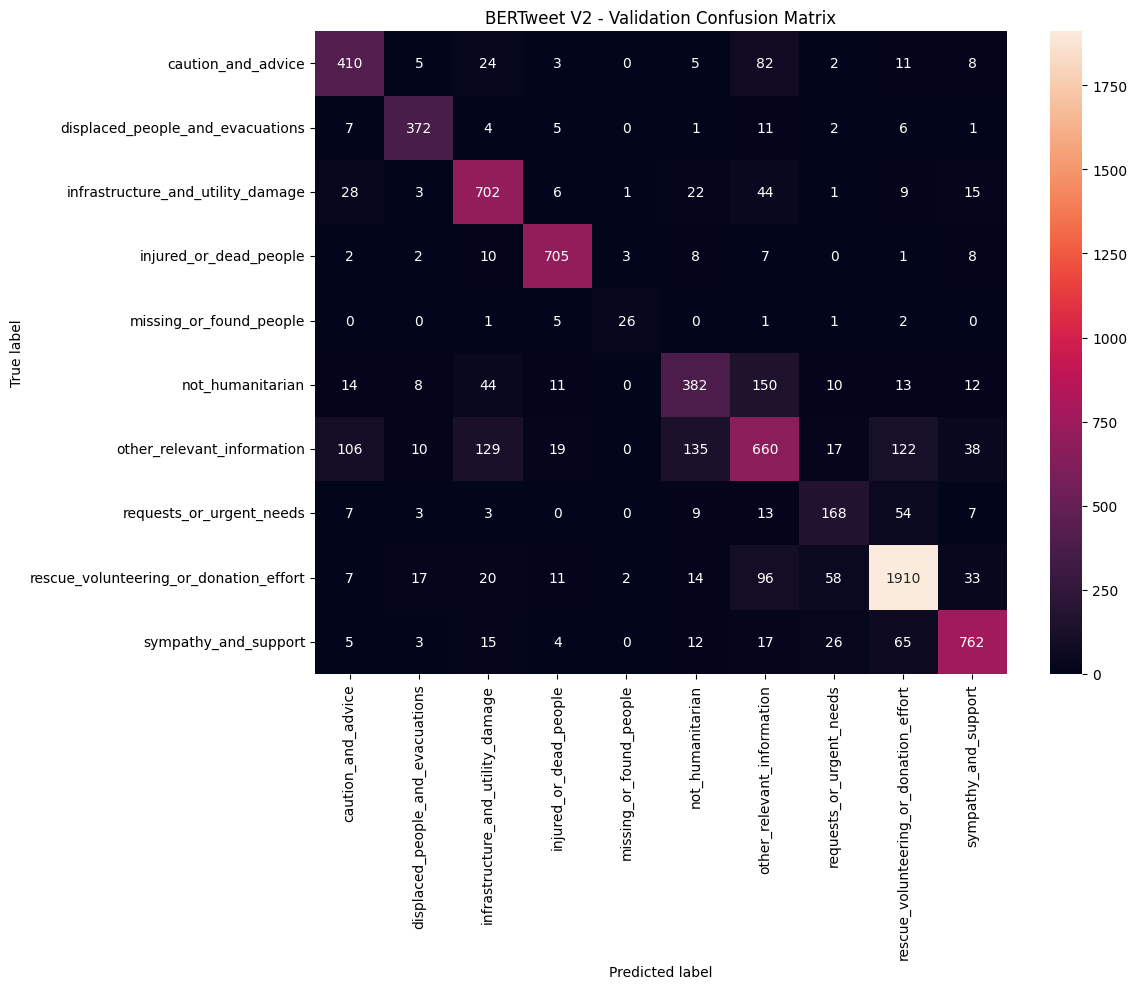

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from BEST V2 model
v2_predictions = bertweet_trainer_v2.predict(bertweet_val)

v2_predicted = v2_predictions.predictions.argmax(axis=1)
v2_true = v2_predictions.label_ids

cm = confusion_matrix(v2_true, v2_predicted)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("BERTweet V2 - Validation Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Get the original validation tweets
validation_results = val_df.copy()

validation_results["true_label"] = [
    labels[i] for i in v2_true
]

validation_results["predicted_label"] = [
    labels[i] for i in v2_predicted
]

# Show the most important confusion:
# other relevant information → not humanitarian

confusion_1 = validation_results[
    (validation_results["true_label"] == "other_relevant_information") &
    (validation_results["predicted_label"] == "not_humanitarian")
]

print("OTHER INFORMATION → NOT HUMANITARIAN")
print("=" * 60)

for i, row in confusion_1.head(20).iterrows():
    print("Tweet:", row["tweet_text"])
    print()


OTHER INFORMATION → NOT HUMANITARIAN
Tweet: @LegupDept Hes not on a HOLIDAY! Hes literally walking through the aftermath destruction of a WILDFIRE!

Tweet: TIL in 2002, a wildfire was started by a lost hiker trying to signal a news helicopter that was itself watching another wildfire started by

Tweet: Tryna find a bright side, plus a little bit of fun facts for you :) #NZeq #earthquake #chile #Argentina #eqnz #NewZealand

Tweet: Not sure if I slept thru aftershocks between 4-6am or if theyre just starting up again in Wellington? #eqnz

Tweet: Aftershocks pls #eqnz

Tweet: #Hillary #Haiti thanks u for the toxic shelters!

Tweet: RT @caltanzee: #The Clintons did 2 the people of Haiti more devastating than the earthquake &amp; hurricane Mathew combined.The Clintons R ma

Tweet: How do you think Bill Clinton &amp; Hillary Clinton tent city made out in that cat 4 Hurricane built sweatshops &amp; mining factory instead Haiti

Tweet: Donald Trump killed Obamas flood protection rule to protec

In [ ]:
from transformers import AutoModelForSequenceClassification

bertweet_model_v4 = AutoModelForSequenceClassification.from_pretrained(
    "vinai/bertweet-base",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

print("Fresh BERTweet V4 loaded!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh BERTweet V4 loaded!


In [ ]:
from transformers import TrainingArguments

bertweet_args_v4 = TrainingArguments(
    output_dir="./resqai_bertweet_v4",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    warmup_steps=500,
    lr_scheduler_type="linear",

    label_smoothing_factor=0.05,

    logging_steps=100,

    report_to="none",

    fp16=True,

    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1
)

In [ ]:
from transformers import Trainer, EarlyStoppingCallback

bertweet_trainer_v4 = Trainer(
    model=bertweet_model_v4,
    args=bertweet_args_v4,

    train_dataset=bertweet_train,
    eval_dataset=bertweet_val,

    compute_metrics=compute_metrics_bertweet,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1
        )
    ]
)

In [ ]:
bertweet_trainer_v4.train()

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 